# 07 — Retrieval Evaluation and Benchmarking

### Purpose

This notebook evaluates and compares the retrieval approaches implemented in the NLP Knowledge Discovery Platform.

The project currently supports:

1. BM25 Retrieval
2. Semantic Retrieval
3. Knowledge Graph-Enhanced Retrieval

The objective is to determine whether semantic retrieval and graph-enhanced retrieval improve scientific document discovery compared to a traditional lexical retrieval baseline.

---

### Research Question

Can semantic representations and knowledge graph information improve scientific document retrieval compared to keyword-based retrieval?

---

### Evaluation Metrics

The following retrieval metrics are used:

#### Precision@K

Measures how many of the retrieved documents are relevant.

#### Recall@K

Measures how many relevant documents were successfully retrieved.

#### Mean Reciprocal Rank (MRR)

Measures how early the first relevant document appears in the ranking.

---

### Expected Outcome

- BM25 should perform well for exact keyword matches.
- Semantic retrieval should improve contextual matching.
- Knowledge Graph-enhanced retrieval should improve ranking quality through graph-based evidence.

## Imports and Setup

In [1]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for candidate in [current, *current.parents]:
    if (candidate / "src").exists() and (candidate / "config.yaml").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.utils.common import setup_notebook

CONFIG, PATHS = setup_notebook()

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform
Config: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\config.yaml
Raw data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\raw
Processed data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed
Graphs: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\graphs
Reports: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports
Figures: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports\figures


In [3]:
tables_dir = PATHS.reports / "tables"

bm25_metrics_path = tables_dir / "bm25_metrics.csv"
semantic_metrics_path = tables_dir / "semantic_metrics.csv"
kg_metrics_path = tables_dir / "kg_enhanced_metrics.csv"

bm25_results_path = tables_dir / "bm25_results.csv"
semantic_results_path = tables_dir / "semantic_results.csv"
kg_results_path = tables_dir / "kg_enhanced_results.csv"

## Validate Experiment Outputs

In [4]:
required_files = [
    bm25_metrics_path,
    semantic_metrics_path,
    kg_metrics_path,
    bm25_results_path,
    semantic_results_path,
    kg_results_path,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following evaluation files are missing:\n"
        + "\n".join(str(path) for path in missing_files)
    )

print("All retrieval experiment outputs found.")

All retrieval experiment outputs found.


## Load Metrics

In [5]:
bm25_metrics = pd.read_csv(bm25_metrics_path)
semantic_metrics = pd.read_csv(semantic_metrics_path)
kg_metrics = pd.read_csv(kg_metrics_path)

print("BM25 Metrics")
display(bm25_metrics)

print("Semantic Retrieval Metrics")
display(semantic_metrics)

print("KG-Enhanced Retrieval Metrics")
display(kg_metrics)

BM25 Metrics


,method,precision@5,recall@5,mrr
0,BM25,0.0,0.0,0.0


Semantic Retrieval Metrics


,method,model,precision@5,recall@5,mrr
0,Semantic,all-MiniLM-L6-v2,0.0,0.0,0.0


KG-Enhanced Retrieval Metrics


,method,retrieval_weight,graph_weight,precision@5,recall@5,mrr
0,KG-enhanced BM25,0.7,0.3,0.0,0.0,0.0


## Build Unified Comparison Table

In [6]:
comparison_df = pd.concat(
    [
        bm25_metrics.assign(method_label="BM25"),
        semantic_metrics.assign(method_label="Semantic"),
        kg_metrics.assign(method_label="KG-Enhanced"),
    ],
    ignore_index=True,
)

comparison_df

,method,precision@5,recall@5,mrr,method_label,model,retrieval_weight,graph_weight
0,BM25,0.0,0.0,0.0,BM25,NaN,NaN,NaN
1,Semantic,0.0,0.0,0.0,Semantic,all-MiniLM-L6-v2,NaN,NaN
2,KG-enhanced BM25,0.0,0.0,0.0,KG-Enhanced,NaN,0.7,0.3


## Ssave Benchmark Table

In [7]:
benchmark_path = (
    PATHS.reports
    / "tables"
    / "retrieval_benchmark_comparison.csv"
)

comparison_df.to_csv(
    benchmark_path,
    index=False,
)

print("Saved benchmark table:")
print(benchmark_path)

Saved benchmark table:
C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports\tables\retrieval_benchmark_comparison.csv


## Precision Comparison

In [8]:
if "precision_at_k" in comparison_df.columns:

    plt.figure(figsize=(8, 5))

    plt.bar(
        comparison_df["method_label"],
        comparison_df["precision_at_k"],
    )

    plt.title("Precision@K Comparison")
    plt.xlabel("Method")
    plt.ylabel("Precision")

    plt.tight_layout()
    plt.show()

## Recall Comparison

In [9]:
if "recall_at_k" in comparison_df.columns:

    plt.figure(figsize=(8, 5))

    plt.bar(
        comparison_df["method_label"],
        comparison_df["recall_at_k"],
    )

    plt.title("Recall@K Comparison")
    plt.xlabel("Method")
    plt.ylabel("Recall")

    plt.tight_layout()
    plt.show()

## MRR Comparison

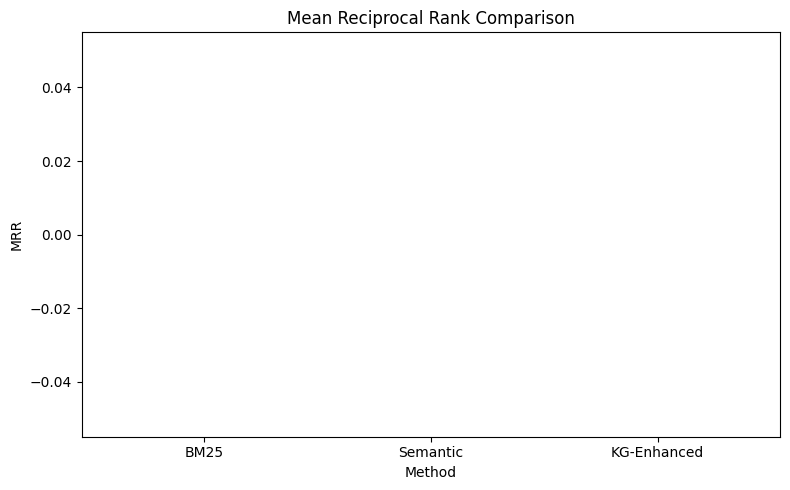

In [10]:
if "mrr" in comparison_df.columns:

    plt.figure(figsize=(8, 5))

    plt.bar(
        comparison_df["method_label"],
        comparison_df["mrr"],
    )

    plt.title("Mean Reciprocal Rank Comparison")
    plt.xlabel("Method")
    plt.ylabel("MRR")

    plt.tight_layout()
    plt.show()

## Load Retrieval Results

In [11]:
bm25_results = pd.read_csv(bm25_results_path)
semantic_results = pd.read_csv(semantic_results_path)
kg_results = pd.read_csv(kg_results_path)

print("BM25 Results:", bm25_results.shape)
print("Semantic Results:", semantic_results.shape)
print("KG Results:", kg_results.shape)

BM25 Results: (50, 7)
Semantic Results: (50, 7)
KG Results: (50, 9)


## Inspect Available Queries

In [12]:
query_ids = sorted(
    set(bm25_results["query_id"])
    | set(semantic_results["query_id"])
    | set(kg_results["query_id"])
)

query_ids

['q1', 'q10', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9']

## Query-Level Comparison

In [13]:
selected_query = query_ids[0]

print("Selected Query:", selected_query)

print("\nBM25")
display(
    bm25_results[
        bm25_results["query_id"] == selected_query
    ]
    .sort_values("rank")
    .head(10)
)

print("\nSemantic Retrieval")
display(
    semantic_results[
        semantic_results["query_id"] == selected_query
    ]
    .sort_values("rank")
    .head(10)
)

print("\nKG-Enhanced Retrieval")
display(
    kg_results[
        kg_results["query_id"] == selected_query
    ]
    .sort_values("rank")
    .head(10)
)

Selected Query: q1

BM25


,query_id,query,rank,doc_id,score,is_relevant,text
0,q1,graph neural networks scientific document retr...,1,1004.3274,20.071920,False,A New Approach to Keyphrase Extraction Using N...
1,q1,graph neural networks scientific document retr...,2,1202.2770,14.713018,False,Multi-Level Error-Resilient Neural Networks wi...
2,q1,graph neural networks scientific document retr...,3,1102.3866,13.901723,False,Treatment of Semantic Heterogeneity in Informa...
3,q1,graph neural networks scientific document retr...,4,712.3298,13.845447,False,CLAIRLIB Documentation v1.03. The Clair libr...
4,q1,graph neural networks scientific document retr...,5,1101.1637,13.673287,False,A Science Model Driven Retrieval Prototype. ...



Semantic Retrieval


,query_id,query,rank,doc_id,score,is_relevant,text
0,q1,graph neural networks scientific document retr...,1,704.2963,0.486430,False,Using Access Data for Paper Recommendations on...
1,q1,graph neural networks scientific document retr...,2,705.2106,0.380717,False,Scientific citations in Wikipedia. The Interne...
2,q1,graph neural networks scientific document retr...,3,705.0751,0.366111,False,Approximate textual retrieval. An approximate ...
3,q1,graph neural networks scientific document retr...,4,704.3359,0.341131,False,Direct Optimization of Ranking Measures. Web p...
4,q1,graph neural networks scientific document retr...,5,704.2902,0.340409,False,Recommending Related Papers Based on Digital L...



KG-Enhanced Retrieval


,query_id,query,rank,doc_id,score,retrieval_score,graph_score,is_relevant,text
0,q1,graph neural networks scientific document retr...,1,704.1028,0.850000,7.498177,1.0,False,A neural network approach to ordinal regressio...
1,q1,graph neural networks scientific document retr...,2,705.4606,0.845635,7.451424,1.0,False,Dynamic User-Defined Similarity Searching in S...
2,q1,graph neural networks scientific document retr...,3,705.0593,0.740864,4.722391,2.0,False,Clustering with Lattices in the Analysis of Gr...
3,q1,graph neural networks scientific document retr...,4,704.3515,0.720126,4.500254,2.0,False,Comparing Robustness of Pairwise and Multiclas...
4,q1,graph neural networks scientific document retr...,5,705.2106,0.710828,6.007416,1.0,False,Scientific citations in Wikipedia. The Interne...


## KG Influence Analysis

In [14]:
kg_columns = [
    column
    for column in [
        "query_id",
        "rank",
        "doc_id",
        "score",
        "base_score",
        "normalized_base_score",
        "graph_score",
        "normalized_graph_score",
        "relevant",
    ]
    if column in kg_results.columns
]

display(
    kg_results[kg_columns]
    .sort_values(["query_id", "rank"])
    .head(20)
)

,query_id,rank,doc_id,score,graph_score
0,q1,1,704.1028,0.850000,1.0
1,q1,2,705.4606,0.845635,1.0
2,q1,3,705.0593,0.740864,2.0
3,q1,4,704.3515,0.720126,2.0
4,q1,5,705.2106,0.710828,1.0
45,q10,1,706.4375,1.000000,2.0
46,q10,2,706.2797,0.561808,1.0
47,q10,3,704.2963,0.538960,2.0
48,q10,4,704.3665,0.467720,1.0
49,q10,5,705.0761,0.375499,2.0


## Ranking Change Analysis

In [15]:
bm25_top_docs = set(
    bm25_results
    .sort_values("rank")
    .head(20)["doc_id"]
)

kg_top_docs = set(
    kg_results
    .sort_values("rank")
    .head(20)["doc_id"]
)

shared_docs = bm25_top_docs.intersection(kg_top_docs)

ranking_change_summary = pd.DataFrame(
    [
        {
            "bm25_top_docs": len(bm25_top_docs),
            "kg_top_docs": len(kg_top_docs),
            "shared_documents": len(shared_docs),
        }
    ]
)

ranking_change_summary

,bm25_top_docs,kg_top_docs,shared_documents
0,16,10,2


## Rettrieval Method Summary

In [16]:
summary_rows = []

for method_name, results_df in [
    ("BM25", bm25_results),
    ("Semantic", semantic_results),
    ("KG-Enhanced", kg_results),
]:
    summary_rows.append(
        {
            "method": method_name,
            "retrieved_rows": len(results_df),
            "unique_documents": results_df["doc_id"].nunique(),
            "queries": results_df["query_id"].nunique(),
        }
    )

summary_df = pd.DataFrame(summary_rows)

summary_df

,method,retrieved_rows,unique_documents,queries
0,BM25,50,37,10
1,Semantic,50,19,10
2,KG-Enhanced,50,22,10


## Save Evaluation Outputs

In [17]:
summary_path = (
    PATHS.reports
    / "tables"
    / "retrieval_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

print("Saved retrieval summary:")
print(summary_path)

Saved retrieval summary:
C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports\tables\retrieval_summary.csv


## Discussion

The retrieval benchmark compares lexical, semantic, and graph-enhanced retrieval strategies.

### BM25

Advantages:

- Fast
- Interpretable
- Strong for exact keyword matching

Limitations:

- Cannot capture semantic similarity
- Sensitive to vocabulary mismatch

---

### Semantic Retrieval

Advantages:

- Captures contextual meaning
- Retrieves conceptually related documents

Limitations:

- Requires embedding models
- Higher computational cost

---

### Knowledge Graph-Enhanced Retrieval

Advantages:

- Incorporates graph structure
- Exploits relationships between concepts
- Improves explainability through graph evidence

Limitations:

- Requires graph construction
- Quality depends on extracted entities and relations

---

### Interpretation

If KG-enhanced retrieval changes the ranking compared to BM25, this demonstrates that graph information contributes additional evidence beyond lexical similarity.

This directly supports the project's central hypothesis that knowledge graphs can improve scientific document discovery.

## Conclusions

This notebook provided a unified evaluation of all retrieval approaches implemented in the project.

Key outcomes:

- BM25 serves as the lexical baseline.
- Semantic retrieval introduces contextual understanding.
- Knowledge Graph-enhanced retrieval incorporates graph structure and relationships.

The benchmark framework enables direct comparison between retrieval methods and provides quantitative evidence for evaluating future improvements.

This notebook represents the final evaluation stage of the retrieval pipeline and serves as the primary benchmark notebook for the project.